In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

%matplotlib inline

In [2]:
np.random.seed(3)  # номер варіанта
daily_temps = np.random.normal(loc=22, scale=2.5, size=30)
np.random.seed()

print("Вибірка денних температур (°C):")
print(np.round(daily_temps, 2))
print("середнє = %.4f" % daily_temps.mean())
print("ст. відхилення = %.4f" % daily_temps.std())

Вибірка денних температур (°C):
[26.47 23.09 22.24 17.34 21.31 21.11 21.79 20.43 21.89 20.81 18.72 24.21
 24.2  26.27 22.13 20.99 20.64 18.13 24.46 19.25 19.04 21.49 25.72 22.59
 19.44 20.22 23.56 21.6  20.08 21.42]
середнє = 21.6877
ст. відхилення = 2.2733


In [3]:
mean = daily_temps.mean()   # mu
std = daily_temps.std()     # sigma
dist = stats.norm(loc=mean, scale=std)   # теоретичний розподіл N(21.6877, 2.2733)

print("mu  = %.4f" % mean)
print("sigma = %.4f" % std)
print("Модель: N(%.4f, %.4f)" % (mean, std))

mu  = 21.6877
sigma = 2.2733
Модель: N(21.6877, 2.2733)


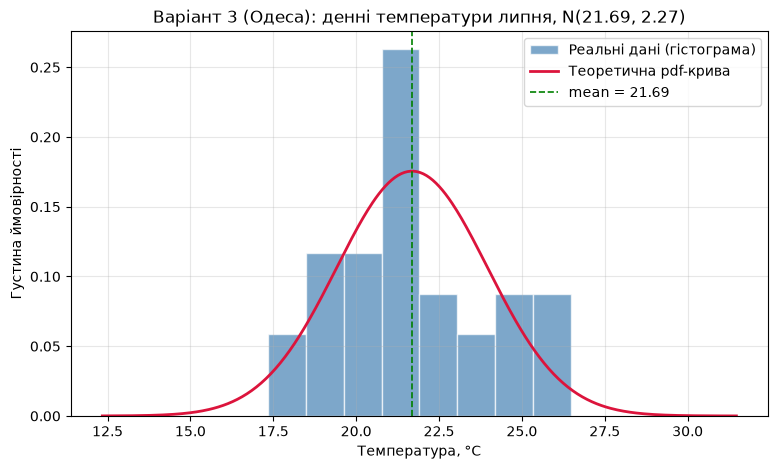

In [4]:
x = np.linspace(daily_temps.min() - 5, daily_temps.max() + 5, 400)

plt.figure(figsize=(9, 5))
plt.hist(daily_temps, bins=8, density=True, edgecolor="white", alpha=0.7,
         color="steelblue", label="Реальні дані (гістограма)")
plt.plot(x, dist.pdf(x), color="crimson", linewidth=2, label="Теоретична pdf-крива")
plt.axvline(mean, color="green", linestyle="--", linewidth=1.2, label="mean = %.2f" % mean)
plt.title("Варіант 3 (Одеса): денні температури липня, N(%.2f, %.2f)" % (mean, std))
plt.xlabel("Температура, °C")
plt.ylabel("Густина ймовірності")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [5]:
left, right = mean - std, mean + std
mask = (daily_temps >= left) & (daily_temps <= right)
p_1sigma = dist.cdf(right) - dist.cdf(left)
emp_1sigma = mask.sum() / daily_temps.size

print("[mean - std, mean + std] = [%.4f, %.4f]" % (left, right))
print("P (теор. модель, cdf)      = %.4f" % p_1sigma)
print("P (емпірично, %d/%d спост.) = %.4f" % (mask.sum(), daily_temps.size, emp_1sigma))


[mean - std, mean + std] = [19.4145, 23.9610]
P (теор. модель, cdf)      = 0.6827
P (емпірично, 19/30 спост.) = 0.6333


In [6]:
p95 = dist.ppf(0.95)

print("95-й процентиль (ppf(0.95)) = %.4f °C" % p95)
print("контроль через cdf: cdf(p95) = %.6f" % dist.cdf(p95))

95-й процентиль (ppf(0.95)) = 25.4270 °C
контроль через cdf: cdf(p95) = 0.950000


## Відповіді на контрольні питання

### 1. Чим відрізняється те, що повертає `.pdf(x)`, від того, що повертає `.cdf(x)`?

Це дві функції, які відповідають на два **різні** питання, і обидві приймають на вхід саме значення x:

- **`.pdf(x)`** — щільність (густина) розподілу в точці x. Відповідає на питання: *«наскільки ймовірна температура, що дорівнює рівно x?»* Повертає **висоту** (густину) кривої над точкою x — це не ймовірність, а швидкість її накопичення.
- **`.cdf(x)`** — накопичена функція розподілу в точці x. Відповідає на питання: *«яка сумарна частка спостережень лежить нижче x?»* Повертає **площу** під кривою pdf ліворуч від x — тобто вже справжню ймовірність.

Зв'язок між ними: `cdf(x) = ∫ pdf(t) dt` від −∞ до x. Для неперервної величини ймовірність «рівно = x» дорівнює нулю, тому `.pdf(x)` ніколи не повертає ймовірність самостійно. Практична різниця: `.pdf` дає **миттєву** картину (де форма крута — там реалізацій багато), а `.cdf` — **накопичену** (скільки всього накопичилось зліва). Приклад: у нашій моделі `pdf(21.69) ≈ 0.1755`, а `cdf(21.69) = 0.5`.

### 2. Чому `.pdf(x)` може повертати число, більше за 1, і чому це не помилка?

Так, це може бути: для нашого розподілу максимум кривої `pdf(mean) ≈ 0.1755`, а якби σ було, скажімо, 0.15 °C, то максимум був би ≈ 2.66 — понад одиницю.

Причина в тому, що **`pdf` повертає не ймовірність, а ймовірність, поділену на одиницю вимірювання**. Тобто це «сила» (щільність) накопичення ймовірності на одиницю інтервалу. Формально для осі X, виміряної в градусах: `f(x) ≈ P(x належить [x, x + dx]) / dx` при dx → 0.

Це не суперечить тому, що ймовірність ≤ 1, оскільки:

1. **Ймовірність — це площа, а не висота.** Помилка було б, якби `.pdf(x)` повертало, скажімо, 2.66 як «частку спостережень, що дорівнюють x». Але це не так: `.pdf(x)` — висота кривої, одиниць «1/°C». Помноживши її на ширину інтервалу в °C, отримуємо ймовірність: `P ≈ 2.66 · 0.1 = 0.266`, тобто 26.6% — цілком коректне число ≤ 1.
2. **Сума, а не максимум.** Інтеграл густини по всьому числовому рядку дорівнює рівно 1. Висота може бути будь-якою — хоча 100, хоча 10000 — важливо лише, щоб **площа під кривою** залишалась одиницею. Ширша криска (менше σ) → вищі піки, але вужчі; вузька → нижчі й ширші.
3. **Одиниці вимірювання.** `.pdf` чутлива до вибору одиниць осі: якщо міняти °C на кельвіни (додавши 273.15), значення pdf зменшиться в 273.15 разів, а ймовірності не зміняться. Практичний висновок: щільність — це не «ймовірність», а «ймовірність на одиницю шкали».

### 3. Чому `.ppf()` називають оберненою до `.cdf()` — що на вхід і на вихід?

**Вхід і вихід у них буквально міняються місцями:**

| | на вхід | на вихід | питання |
|---|---|---|---|
| `.cdf(x)` | значення x | ймовірність (0..1) | «Яка частка даних ≤ x?» |
| `.ppf(q)` | ймовірність q (0..1) | значення x | «Яке значення відповідає частці q?» |

Тому вони називаються прямими та зворотними відповідно: `.cdf` перетворює значення на ймовірність (пряме перетворення), а `.ppf` робить зворотний крок — знаходить значення за заданою ймовірністю. Це та сама логіка, що й для sin/sin⁻¹: `sin⁻¹(sin(π/6)) = π/6`.

Формально `ppf` — це функція, **зворотна** до cdf: `cdf(ppf(q)) = q` для будь-якого q. Це перевірено вище: `dist.cdf(dist.ppf(0.95)) = 0.950000`. Тому вона ще називається **квантильною функцією**: на осі Y замість накопиченої ймовірності (0..1) відкладається сама температура, а крива зростає від −∞ до +∞.

У нашому прикладі: `.cdf(25.43) = 0.95` — «95% днів нижче 25.43 °C», а `.ppf(0.95) = 25.43` — «температура, нижче якої 95% днів». Обидва твердження описують ту саму точку на тій самій кривій, але рухаються по осі в протилежних напрямках.

## Підсумок

| Величина | Значення |
|---|---|
| Варіант / місто | 3 — Одеса |
| Липневе середнє з таблиці | 22 °C |
| μ = mean вибірки | **21.6877 °C** |
| σ = std вибірки | **2.2733 °C** |
| Модель | N(21.6877, 2.2733) |
| P(X ∈ [μ−σ, μ+σ]) через cdf | **0.6827** (емпірично 19/30 = 0.633) |
| 95-й процентиль через ppf | **25.4270 °C** |
| pdf у точці μ | ≈ 0.1755 |

Параметри нормального розподілу підібрано безпосередньо з власної вибірки; гістограма й теоретична pdf-крива накладено в узгоджених одиницях (`density=True`); `.cdf()` застосовано для ймовірності в діапазоні, `.ppf()` — для пошуку квантиля за заданою накопиченою ймовірністю.